# Fraud Detection Machine Learning Project

This notebook builds a simple fraud detection model using customer data.

In [0]:
# Install packages we need
%pip install scikit-learn matplotlib seaborn --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Machine learning stuff
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import mlflow
import mlflow.sklearn

print("Libraries loaded!")
print(f"Today's date: {datetime.now().strftime('%Y-%m-%d')}")

/databricks/python/lib/python3.11/site-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


Libraries loaded!
Today's date: 2026-04-19


In [0]:
# Load data from database
df = spark.table("ddca_catalog.gold.ml_fraud_features")

# Convert to pandas (easier to work with)
df_pandas = df.toPandas()

print(f"Loaded {len(df_pandas)} customers")
print(f"Number of columns: {len(df_pandas.columns)}")
print("\nFirst few rows:")
display(df_pandas.head())

Loaded 3000 customers
Number of columns: 25

First few rows:


customer_id,age,income,country,risk_score,account_age,age_group,risk_category,total_transactions,fraud_count,fraud_percentage,avg_distance_from_home,avg_purchase_ratio,online_order_count,total_messages,first_message_time,last_message_time,avg_message_length,days_since_last_chat,online_transaction_ratio,is_engaged_customer,is_high_risk,has_fraud_history,transactions_per_year,feature_timestamp
2936,5,112694,US,0.8040835,3,young,high,45,6,13.33,23.394427967733808,2.0892916480700174,31,0,null,null,0.0,null,0.6888888888888889,0,1,1,15.0,2026-04-19T18:59:16.517Z
1021,17,58734,SINGAPORE,0.015551299,6,young,low,64,5,7.81,23.214935428462923,1.6241899053566158,40,3,2026-01-21T12:27:21.447Z,2026-03-31T07:01:56.078Z,27.666666666666668,19.0,0.625,1,0,1,10.666666666666666,2026-04-19T18:59:16.517Z
2737,15,58249,SINGAPORE,0.9673403,6,young,high,23,0,0.0,14.260771492901055,2.269613300328669,14,3,2026-01-01T15:59:55.161Z,2026-03-17T20:46:19.296Z,26.666666666666668,33.0,0.6086956521739131,1,1,0,3.8333333333333335,2026-04-19T18:59:16.517Z
1721,30,152436,FRANCE,0.018880792,1,middle_aged,low,23,6,26.09,21.71957008216692,1.7792133925401645,14,2,2026-03-30T12:42:19.157Z,2026-04-16T15:05:52.827Z,28.5,3.0,0.6086956521739131,1,0,1,23.0,2026-04-19T18:59:16.517Z
94,24,36774,FRANCE,0.3057546,6,young,low,22,14,63.64,39.87053876776587,3.968323990702629,19,0,null,null,0.0,null,0.8636363636363636,0,0,1,3.6666666666666665,2026-04-19T18:59:16.517Z


Data shape (rows, columns): (3000, 25)

Column types:
customer_id                          int32
age                                  int32
income                               int32
country                             object
risk_score                         float32
account_age                          int32
age_group                           object
risk_category                       object
total_transactions                   int64
fraud_count                          int64
fraud_percentage                   float64
avg_distance_from_home             float64
avg_purchase_ratio                 float64
online_order_count                   int64
total_messages                       int64
first_message_time          datetime64[ns]
last_message_time           datetime64[ns]
avg_message_length                 float64
days_since_last_chat               float64
online_transaction_ratio           float64
is_engaged_customer                  int32
is_high_risk                         int32


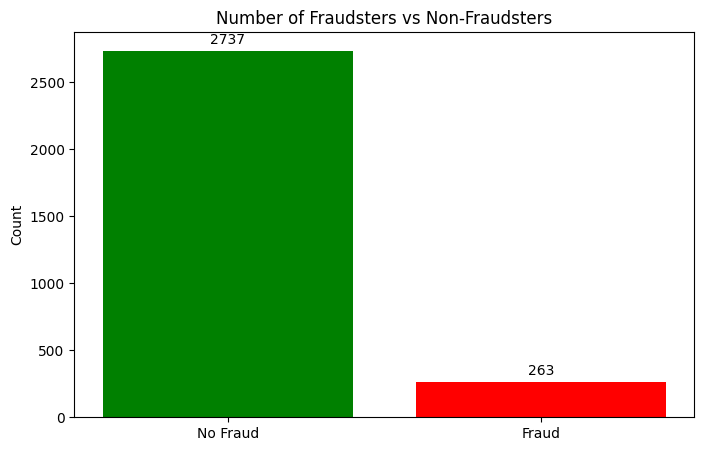

In [0]:
# Look at the data
print("Data shape (rows, columns):", df_pandas.shape)
print("\nColumn types:")
print(df_pandas.dtypes)

# Check for missing values
print("\nMissing values:")
print(df_pandas.isnull().sum())

# Look at our target - has_fraud_history (0 = no fraud, 1 = fraud)
print("\nHow many fraudsters vs non-fraudsters?")
print(df_pandas['has_fraud_history'].value_counts())

# Make a simple bar chart
fraud_counts = df_pandas['has_fraud_history'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(['No Fraud', 'Fraud'], fraud_counts.values, color=['green', 'red'])
plt.title('Number of Fraudsters vs Non-Fraudsters')
plt.ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

In [0]:
# Basic statistics for numerical columns
print("Basic statistics:")
display(df_pandas.describe())

# Look at categorical columns
print("\nCountries in the data:")
print(df_pandas['country'].value_counts().head(10))

print("\nAge groups:")
print(df_pandas['age_group'].value_counts())

print("\nRisk categories:")
print(df_pandas['risk_category'].value_counts())

Basic statistics:


customer_id,age,income,risk_score,account_age,total_transactions,fraud_count,fraud_percentage,avg_distance_from_home,avg_purchase_ratio,online_order_count,total_messages,avg_message_length,days_since_last_chat,online_transaction_ratio,is_engaged_customer,is_high_risk,has_fraud_history,transactions_per_year
3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,1889.0,3000.0,3000.0,3000.0,3000.0,2999.0
1500.5,30.342666666666666,110572.994,0.27097246050834656,3.0096666666666665,233.72533333333334,12.686333333333334,36.82386666666666,38.281560270154024,3.110770664213364,149.51466666666667,1.006,17.021811111111113,45.5420857596612,0.7413581480478304,0.6296666666666667,0.07166666666666667,0.9123333333333333,53.60589640991441
866.1697293256098,16.903110698112535,51612.081985715944,0.22866469621658325,1.9998932671309055,8905.716872673996,9.264442231034362,23.17374028065144,19.15979776210079,1.2837577581645003,5536.519611114275,1.0170097195159264,13.287806583579759,31.349324393469203,0.11184174887753841,0.4829744406546418,0.25797817698820236,0.2828566624978018,1494.6416810185838
1.0,1.0,20127.0,1.22192195703974E-5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
750.75,16.0,66726.0,0.10504227876663208,1.0,20.0,5.0,16.427500000000002,24.619220469560886,2.063910943157971,14.0,0.0,0.0,18.0,0.6666666666666666,0.0,0.0,1.0,3.6666666666666665
1500.5,31.0,110888.0,0.2075265422463417,3.0,30.0,11.0,35.95,34.19494576755271,2.9910385926720884,23.0,1.0,25.0,42.0,0.75,1.0,0.0,1.0,8.0
2250.25,45.0,154434.0,0.37739167362451553,5.0,44.0,19.0,56.25,47.497941248503466,4.021746222618158,34.0,2.0,27.0,71.0,0.8260869565217391,1.0,0.0,1.0,17.0
3000.0,59.0,199984.0,0.9999802112579346,6.0,487278.0,45.0,96.43,170.2404807806015,14.233769845962524,302927.0,6.0,39.0,108.0,1.0,1.0,1.0,1.0,81213.0



Countries in the data:
SINGAPORE     279
AZERBAIJAN    275
BRAZIL        273
CANADA        257
INDIA         256
US            251
NIGERIA       248
RUSSIA        245
GERMANY       238
FRANCE        237
Name: country, dtype: int64

Age groups:
young          1209
middle_aged    1021
senior          770
Name: age_group, dtype: int64

Risk categories:
low       2302
medium     483
high       215
Name: risk_category, dtype: int64


Correlation with fraud (has_fraud_history):
has_fraud_history           1.000000
online_transaction_ratio    0.308541
avg_distance_from_home      0.246801
income                      0.010536
age                         0.007889
risk_score                 -0.021879
total_transactions         -0.070836
Name: has_fraud_history, dtype: float64


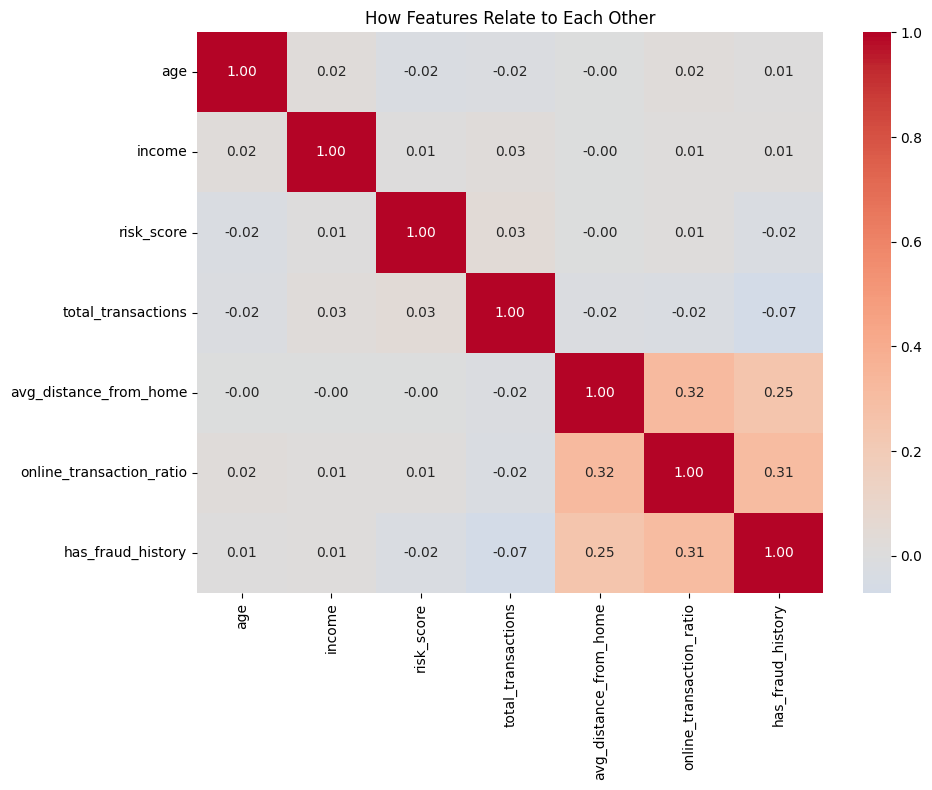

In [0]:
# Let's see which features are related to fraud
# Pick some important numerical features
important_features = [
    'age', 'income', 'risk_score', 'total_transactions',
    'avg_distance_from_home', 'online_transaction_ratio',
    'has_fraud_history'
]

# Calculate correlations
corr = df_pandas[important_features].corr()

# Show correlation with fraud
print("Correlation with fraud (has_fraud_history):")
fraud_corr = corr['has_fraud_history'].sort_values(ascending=False)
print(fraud_corr)

# Make a simple heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('How Features Relate to Each Other')
plt.tight_layout()
plt.show()

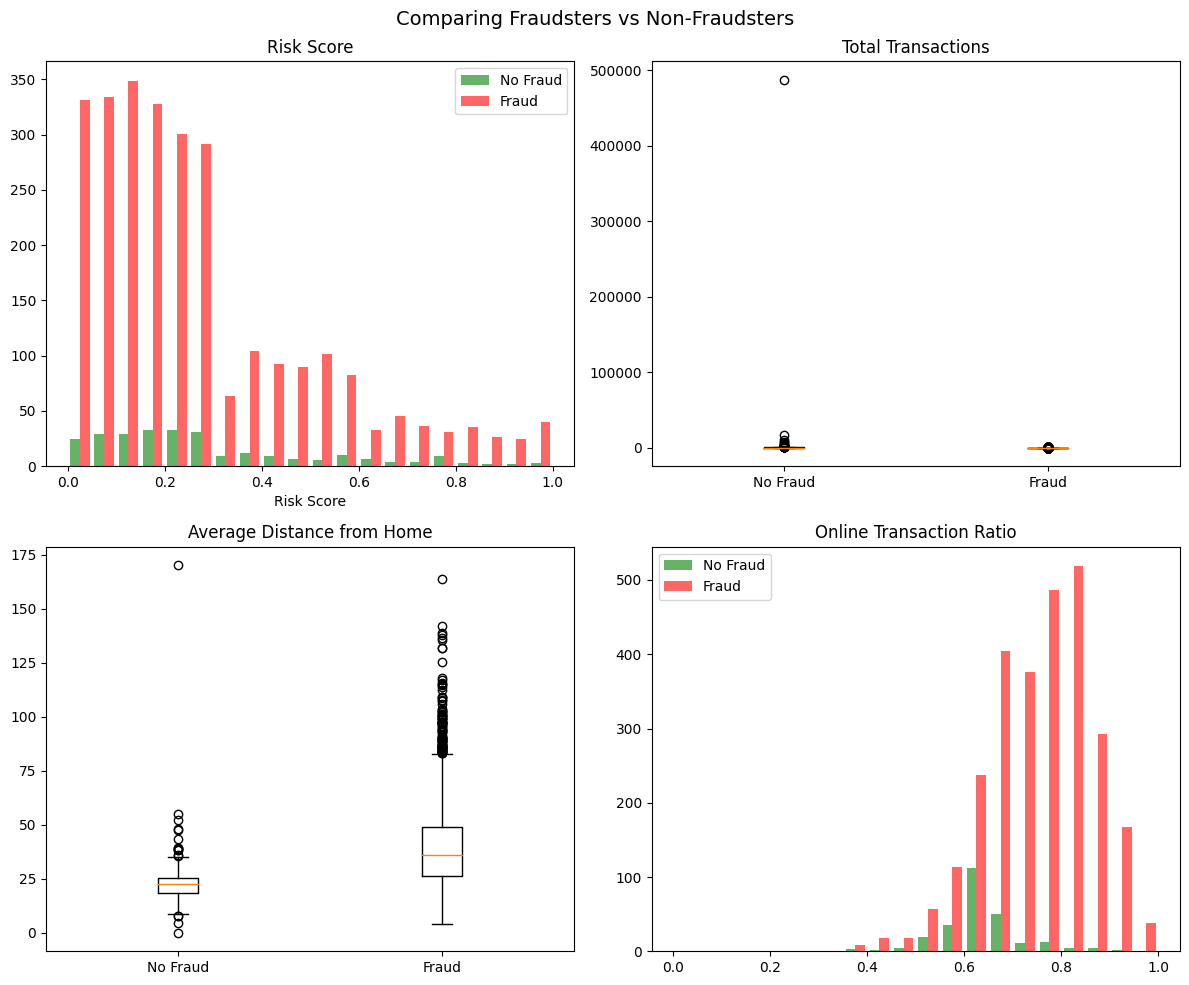

In [0]:
# Compare fraudsters vs non-fraudsters on some features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparing Fraudsters vs Non-Fraudsters', fontsize=14)

# Risk score comparison
fraud_data = df_pandas[df_pandas['has_fraud_history'] == 1]['risk_score']
no_fraud_data = df_pandas[df_pandas['has_fraud_history'] == 0]['risk_score']
axes[0, 0].hist([no_fraud_data, fraud_data], label=['No Fraud', 'Fraud'], bins=20, color=['green', 'red'], alpha=0.6)
axes[0, 0].set_title('Risk Score')
axes[0, 0].set_xlabel('Risk Score')
axes[0, 0].legend()

# Total transactions
fraud_data = df_pandas[df_pandas['has_fraud_history'] == 1]['total_transactions']
no_fraud_data = df_pandas[df_pandas['has_fraud_history'] == 0]['total_transactions']
axes[0, 1].boxplot([no_fraud_data, fraud_data], labels=['No Fraud', 'Fraud'])
axes[0, 1].set_title('Total Transactions')

# Distance from home
fraud_data = df_pandas[df_pandas['has_fraud_history'] == 1]['avg_distance_from_home']
no_fraud_data = df_pandas[df_pandas['has_fraud_history'] == 0]['avg_distance_from_home']
axes[1, 0].boxplot([no_fraud_data, fraud_data], labels=['No Fraud', 'Fraud'])
axes[1, 0].set_title('Average Distance from Home')

# Online ratio
fraud_data = df_pandas[df_pandas['has_fraud_history'] == 1]['online_transaction_ratio']
no_fraud_data = df_pandas[df_pandas['has_fraud_history'] == 0]['online_transaction_ratio']
axes[1, 1].hist([no_fraud_data, fraud_data], label=['No Fraud', 'Fraud'], bins=20, color=['green', 'red'], alpha=0.6)
axes[1, 1].set_title('Online Transaction Ratio')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [0]:
# Prepare data for machine learning
print("Preparing data...")

df_ml = df_pandas.copy()

# Drop columns
columns_to_drop = [
    'customer_id',
    'fraud_count',
    'fraud_percentage',
    'first_message_time',
    'last_message_time',
    'feature_timestamp'
]
df_ml = df_ml.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns")
print(f"Now we have {len(df_ml.columns)} columns left")

Preparing data...
Dropped 6 columns
Now we have 19 columns left


In [0]:
# Handle missing values (fill with 0 for simplicity)
df_ml = df_ml.fillna(0)
print("Filled missing values with 0")

# Convert categorical columns to numbers
# pandas get_dummies creates new columns for each category
df_ml = pd.get_dummies(df_ml, columns=['country', 'age_group', 'risk_category'], drop_first=True)
print(f"After converting categories, we have {len(df_ml.columns)} columns")

# Separate features (X) from target (y)
y = df_ml['has_fraud_history'] # Target prediction feature
X = df_ml.drop('has_fraud_history', axis=1)

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {len(X_train)} customers")
print(f"Test set: {len(X_test)} customers")

Filled missing values with 0
After converting categories, we have 31 columns

Features shape: (3000, 30)
Target shape: (3000,)

Training set: 2400 customers
Test set: 600 customers


In [0]:
# Train a Random Forest model
print("Training the model...")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training complete!")
print(f"Used {len(X_train)} customers to train")
print(f"Model has {model.n_estimators} trees")

Training the model...
Model training complete!
Used 2400 customers to train
Model has 100 trees


In [0]:
print("Testing the model...\n")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance:")
print(f"Accuracy: {accuracy:.2%} (how often it's correct)")
print(f"Precision: {precision:.2%} (when it says fraud, how often is it right)")
print(f"Recall: {recall:.2%} (how many frauds did it catch)")
print(f"F1 Score: {f1:.2%} (overall score combining precision and recall)")

print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['No Fraud', 'Fraud']))

Testing the model...

Model Performance:
Accuracy: 96.83% (how often it's correct)
Precision: 97.37% (when it says fraud, how often is it right)
Recall: 99.29% (how many frauds did it catch)
F1 Score: 98.32% (overall score combining precision and recall)

Detailed Report:
              precision    recall  f1-score   support

    No Fraud       0.86      0.62      0.72        40
       Fraud       0.97      0.99      0.98       560

    accuracy                           0.97       600
   macro avg       0.92      0.81      0.85       600
weighted avg       0.97      0.97      0.97       600



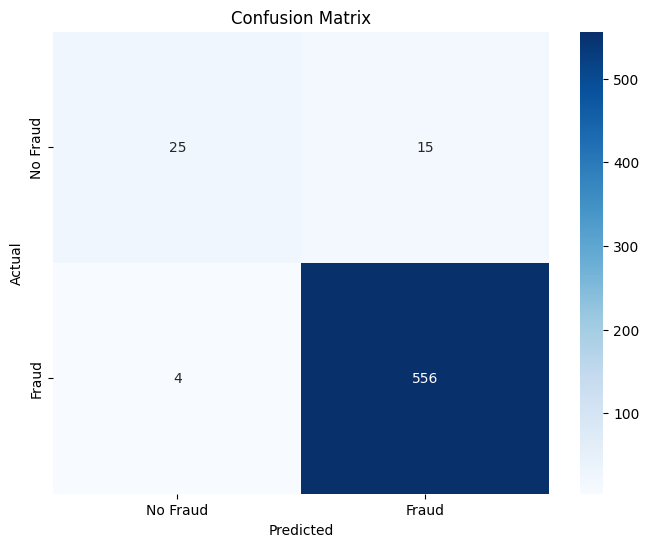


What this means:
Correctly identified non-fraudsters: 25
Wrongly flagged as fraud: 15
Missed frauds: 4
Correctly caught frauds: 556


In [0]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nWhat this means:")
print(f"Correctly identified non-fraudsters: {cm[0, 0]}")
print(f"Wrongly flagged as fraud: {cm[0, 1]}")
print(f"Missed frauds: {cm[1, 0]}")
print(f"Correctly caught frauds: {cm[1, 1]}")

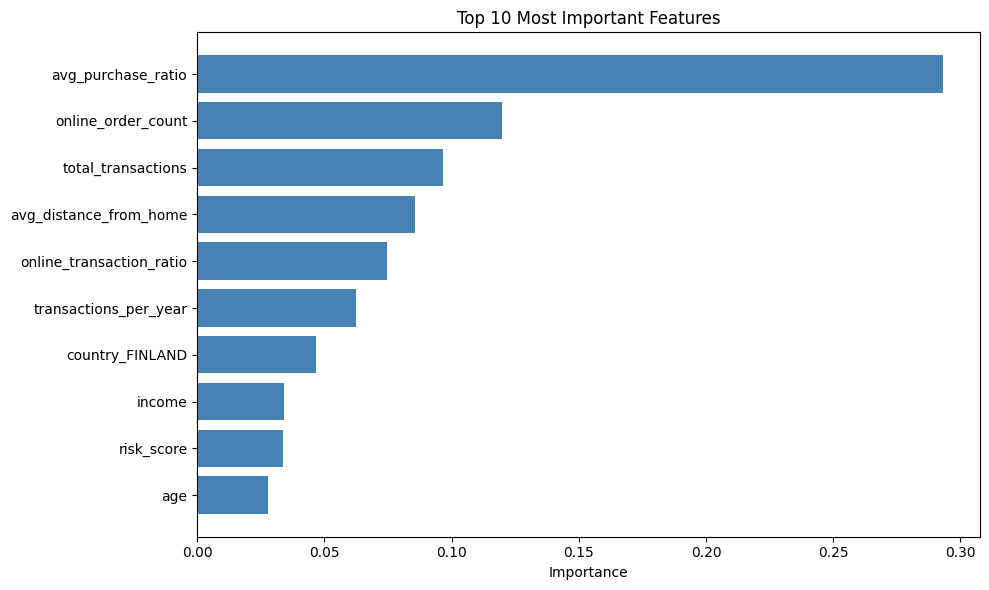


These features helped the model decide if someone is a fraudster


In [0]:
importances = model.feature_importances_
feature_names = X.columns

# Top 10 most important features
indices = np.argsort(importances)[-10:]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_importances, color='steelblue')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

print("\nThese features helped the model decide if someone is a fraudster")

In [0]:
print("\nModel metrics:")
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1 Score: {f1:.2%}")


Model metrics:
Accuracy: 96.83%
Precision: 97.37%
Recall: 99.29%
F1 Score: 98.32%


In [0]:
print("Making predictions for all customers...\n")

all_predictions = model.predict(X)
all_probabilities = model.predict_proba(X)[:, 1]  # Probability of being fraud

results = pd.DataFrame({
    'customer_id': df_pandas['customer_id'],
    'actual_fraud': df_pandas['has_fraud_history'],
    'predicted_fraud': all_predictions,
    'fraud_probability': all_probabilities
})

results['risk_level'] = 'Low'
results.loc[results['fraud_probability'] > 0.3, 'risk_level'] = 'Medium'
results.loc[results['fraud_probability'] > 0.7, 'risk_level'] = 'High'

print(f"Made predictions for {len(results)} customers")
print(f"\nRisk levels:")
print(results['risk_level'].value_counts())

print("\nSample predictions:")
display(results.head(10))

Making predictions for all customers...

Made predictions for 3000 customers

Risk levels:
High      2711
Low        175
Medium     114
Name: risk_level, dtype: int64

Sample predictions:


customer_id,actual_fraud,predicted_fraud,fraud_probability,risk_level
2936,1,1,0.9958081051592594,High
1021,1,1,0.7486342647225345,High
2737,0,0,0.43994541123027064,Medium
1721,1,1,0.980903179923224,High
94,1,1,0.9996404444832929,High
2332,1,1,0.9998582903366446,High
1329,1,1,0.9998166955807781,High
1257,1,1,0.99986940843861,High
1007,1,1,0.984541028223331,High
991,1,1,0.9959046457861706,High


In [0]:
print("Saving predictions to database...\n")

results_spark = spark.createDataFrame(results)

# Save
table_name = "ddca_catalog.gold.customer_fraud_predictions"
results_spark.write.mode("overwrite").saveAsTable(table_name)

print(f"Saved to {table_name}")
print(f"Total predictions saved: {len(results)}")

print("\nVerifying saved data:")
saved_data = spark.table(table_name)
display(saved_data.limit(5))

Saving predictions to database...

Saved to ddca_catalog.gold.customer_fraud_predictions
Total predictions saved: 3000

Verifying saved data:


customer_id,actual_fraud,predicted_fraud,fraud_probability,risk_level
141,1,1,0.9969274492818344,High
165,1,1,0.9872808241764724,High
105,1,1,0.9998877547719913,High
380,1,1,0.9898105216398804,High
1789,1,1,0.9986794441696882,High
